# 社會網絡分析與地理應用 期中考

資訊工程學系 三年級 吳佳泰 S1254059

## 試題提供的檔案為某系所 100 位學生的修課紀錄，假設兩位學生共同修習某一門課可代表兩位學生之間存在接觸關係，並且有可能因此造成傳染病的傳播，請回答下列問題：


In [157]:
import numpy as np
import networkx as nx
import pandas as pd
from operator import itemgetter

In [158]:
df = pd.read_csv("class_data.csv")
n = df.values
df

,Student,Course_1,Course_2,Course_3,Course_4,Course_5,Course_6,Course_7,Course_8,Course_9,...,Course_21,Course_22,Course_23,Course_24,Course_25,Course_26,Course_27,Course_28,Course_29,Course_30
0,Student_1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,Student_2,1,0,0,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,Student_3,1,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,Student_4,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,Student_5,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Student_96,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
96,Student_97,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
97,Student_98,0,0,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
98,Student_99,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1


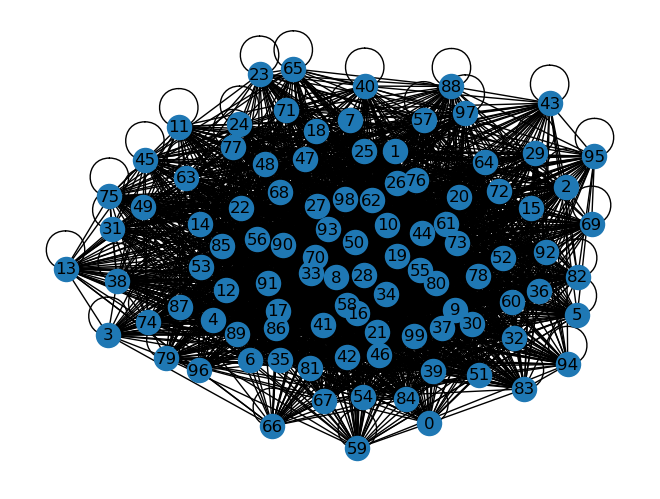

In [159]:
df.drop("Student", axis=1, inplace=True)
n = df.values@df.values.T
g = nx.from_numpy_array(n)
nx.draw(g, with_labels=True)

### 1.假設個人感染疾病的風險與他人接觸次數成正比，請問哪一位學生的感染風險最高？（10%）

> Ans：第 71 位(Python 編號從 0 開始)，因為該生的 Degree centrality 最高，表示鄰居數量最多

In [160]:
list1 = list(sorted(nx.degree_centrality(g).items(),key=itemgetter(1), reverse=True))
print(list1[0])

(70, 0.9090909090909092)


### 2. 根據經驗，在傳染病疫情中，大多數民眾只會傳播疾病給予周遭的人；只有少數的超級傳播者具有異常大量與他人接觸的頻率，進而造成大規模擴散。請問在學生網絡中，是否存在此現象？（20%）

> Ans：否，因為根據每個學生的 Degree centrality 來看，並沒有出現極高的值

In [161]:
for i in list1:
    print(i)

(70, 0.9090909090909092)
(33, 0.888888888888889)
(80, 0.8787878787878789)
(58, 0.8686868686868687)
(28, 0.8383838383838385)
(50, 0.8383838383838385)
(19, 0.8282828282828284)
(93, 0.8282828282828284)
(8, 0.8181818181818182)
(16, 0.8181818181818182)
(10, 0.797979797979798)
(17, 0.7676767676767677)
(26, 0.7575757575757577)
(34, 0.7575757575757577)
(62, 0.7575757575757577)
(27, 0.7373737373737375)
(90, 0.7272727272727273)
(41, 0.7171717171717172)
(55, 0.7171717171717172)
(44, 0.7070707070707072)
(99, 0.686868686868687)
(46, 0.6666666666666667)
(89, 0.6666666666666667)
(76, 0.6464646464646465)
(4, 0.6363636363636365)
(21, 0.6363636363636365)
(56, 0.6363636363636365)
(81, 0.6363636363636365)
(85, 0.6363636363636365)
(30, 0.6262626262626263)
(60, 0.6262626262626263)
(73, 0.6262626262626263)
(35, 0.6161616161616162)
(42, 0.6161616161616162)
(61, 0.6161616161616162)
(86, 0.6161616161616162)
(12, 0.6060606060606061)
(68, 0.6060606060606061)
(98, 0.6060606060606061)
(22, 0.595959595959596)
(37, 0

### 3. 如果要採取防疫隔離措施，請以結構洞的觀點分析哪些學生應該優先被隔離，避免傳染病擴散到所有學生身上？（20%）

> Ans：以結構洞的觀點來說，我們可以找出每個節點的 constraint 的最小值和 effective size 最大值，藉此找出最重要的聯繫者來隔離，將群體分散，在此學生網路中。第 71 位學生為最重要的聯繫者(Python 編號從 0 開始)

In [162]:
# Constraint
list1 = list(nx.constraint(g).keys())
list2 = list(nx.constraint(g).values())
print("Minimum constraint :" ,list1[list2.index(min(list2))], "； Constraint value :", min(list2))

# Effective size
list3 = list(nx.effective_size(g).keys())
list4 = list(nx.effective_size(g).values())
print("Maximum effective size :" , list3[list4.index(max(list4))], "； Effective size value :", max(list4))

Minimum constraint : 70 ； Constraint value : 0.04187381597880014
Maximum effective size : 70 ； Effective size value : 36.45454545454545


### 4. 呈上題，如果是採用節點中心性的觀點，哪些學生應該優先被隔離？請選擇一種中心性指標進行分析並說明選擇該指標的原因（20%）

> Ans：使用 betweenness centrality 指標進行中性性指標分析，原因是可以找出多少最短路徑會經過自己，藉此找出中心傳播者，透過隔離 betweenness centrality 較高的學生，能使最短路徑變長，甚至將群體分割。在此學生網路內，第 71 位學生(Python 編號從 0 開始)為 betweenness 最高的人

In [167]:
sorted(nx.betweenness_centrality(g).items(),key=itemgetter(1), reverse=True)

[(70, 0.014407970078376698),
 (33, 0.013256331880943453),
 (58, 0.012258867385496135),
 (80, 0.012085479512790437),
 (50, 0.01204456648799209),
 (93, 0.010947401826363085),
 (28, 0.010677664821226557),
 (19, 0.010515101065208136),
 (16, 0.010494469827786203),
 (8, 0.010195058074126608),
 (10, 0.010134303367088357),
 (62, 0.009850407582224047),
 (26, 0.009556094915017053),
 (27, 0.009136334973222396),
 (17, 0.00861822324364802),
 (90, 0.008192478005224529),
 (34, 0.007793346463748166),
 (55, 0.007692825489687644),
 (44, 0.007109868709935298),
 (41, 0.006696980121745576),
 (99, 0.006323155619679211),
 (76, 0.005873953161261197),
 (46, 0.00580552962047152),
 (85, 0.005379556339664893),
 (73, 0.005221841303880893),
 (61, 0.005196164352801787),
 (68, 0.005120094498978439),
 (56, 0.004996645356481498),
 (12, 0.004984432637580925),
 (89, 0.004973105188548631),
 (60, 0.004938376405159669),
 (98, 0.004934115903566452),
 (78, 0.0048325371170295575),
 (86, 0.004769833869830265),
 (42, 0.004724211

### 5. 由於傳染病具備群聚感染的特性，所以使用 clique 小群體管理會是較理想的防疫策略。請問在學生的接觸網絡中，總共有幾個 clique 存在？最大的 clique 有多大？（10%）

> Ans：一共有 13941 個 clique ，最大的 clique level 為 27

In [164]:
cliques = [x for x in nx.find_cliques(g)]  
max_level = max(len(x) for x in cliques)

print("(1)Number of cliques :", len(cliques))
print("(2)Maximum level cliques :", max_level)

cliques

(1)Number of cliques : 13941
(2)Maximum level cliques : 27


[[2, 80, 67, 16, 9, 60, 57, 10, 56, 62, 8, 73, 55],
 [2, 80, 67, 16, 9, 60, 57, 10, 56, 62, 36],
 [2, 80, 67, 16, 9, 60, 28, 8, 73, 55, 91, 10, 20, 56],
 [2, 80, 67, 16, 9, 60, 28, 8, 73, 55, 91, 10, 20, 51, 99],
 [2, 80, 67, 16, 9, 60, 28, 8, 73, 55, 91, 10, 62, 56],
 [2, 80, 67, 16, 9, 60, 28, 8, 73, 55, 91, 30, 20, 56],
 [2, 80, 67, 16, 9, 60, 28, 8, 73, 55, 91, 30, 20, 99, 51],
 [2, 80, 67, 16, 9, 60, 28, 8, 86, 20, 56, 10],
 [2, 80, 67, 16, 9, 60, 28, 8, 86, 20, 56, 30],
 [2, 80, 67, 16, 9, 60, 28, 8, 86, 20, 99, 51, 10],
 [2, 80, 67, 16, 9, 60, 28, 8, 86, 20, 99, 51, 30],
 [2, 80, 67, 16, 9, 60, 28, 36, 62, 56, 10],
 [2, 80, 67, 16, 9, 60, 28, 36, 62, 56, 52],
 [2, 80, 67, 16, 9, 60, 28, 36, 86, 56, 10],
 [2, 80, 67, 16, 9, 60, 28, 36, 86, 56, 52, 30],
 [2, 80, 67, 16, 9, 60, 28, 36, 86, 99, 10],
 [2, 80, 67, 16, 9, 60, 28, 36, 86, 99, 30],
 [2, 80, 67, 16, 9, 60, 28, 52, 20, 30, 56, 86],
 [2, 80, 67, 16, 9, 60, 28, 52, 20, 30, 56, 55],
 [2, 80, 67, 16, 9, 60, 28, 52, 20, 30, 51,

### 6. 為了擴大考量可能的潛在接觸傳播，針對接觸網絡進行分群分析，能夠同時匡列確診者與高風險的學生。在假設編號 11 的學生確診的情況下，請列出應該密切關注的高風險學生名單。 （10%）

> Ans：程式碼輸出結果由大到小列出每位與編號 11 的同學接觸的次數(參與同個課程的數量)，此為密切關注的高風險學生名單

In [165]:
print("Stuent", "Connect with No.11 times", sep="\t")

list1 = list(n[10].copy())
list2 = []
counter = 0

for i in range(len(list1)):
    list2.append([list1[i], i])

list2.sort()
list2.reverse()

for i in list2:
    if (i[0] != 0 and i[1] != 10):
        print(i[1]+1, i[0], sep="\t")



Stuent	Connect with No.11 times
9	5
81	4
62	4
56	4
34	4
94	3
93	3
79	3
63	3
59	3
58	3
33	3
27	3
20	3
17	3
10	3
100	2
95	2
92	2
87	2
86	2
77	2
74	2
73	2
71	2
66	2
57	2
52	2
51	2
49	2
46	2
42	2
41	2
38	2
36	2
35	2
30	2
29	2
24	2
23	2
22	2
19	2
16	2
6	2
99	1
96	1
91	1
90	1
89	1
88	1
85	1
84	1
82	1
76	1
75	1
72	1
68	1
64	1
61	1
60	1
55	1
50	1
48	1
47	1
44	1
43	1
40	1
39	1
37	1
32	1
26	1
21	1
15	1
12	1
8	1
5	1
3	1


### 7. 呈上題，如果想要在每一個分群裡面都挑選一位同學進行防疫隔離，請問應該挑選哪幾位同學？挑選的理由為何？（10%）

> Ans：分群內與編號 11 接觸最多的同學，因為它們是高風險群

Community 1 : {32, 5, 8, 9, 10, 80, 51, 54, 55, 92, 61}
Community 2 : {96, 66, 68, 69, 70, 39, 44, 28, 46, 53, 24, 60}
Community 3 : {33, 38, 74, 75, 11, 13, 45, 49, 86, 22, 31}
Community 4 : {0, 4, 6, 70, 74, 12, 79, 81, 17, 21, 89, 33, 39, 41, 46, 58, 59}
Community 5 : {98, 36, 72, 42, 44, 15, 82, 83, 19, 26, 27, 29}
Community 6 : {50, 37, 7, 90, 76, 29, 78}
Community 7 : {65, 97, 67, 71, 73, 14, 79, 48, 84, 23, 25, 57, 62, 95}


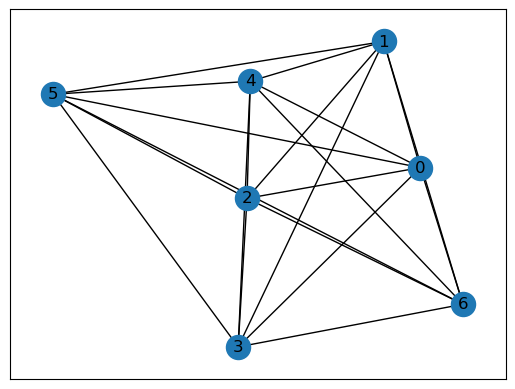

In [179]:
n = nx.community.louvain_communities(g)

for i in range(len(n)):
    print("Community", i+1, ":", nx.community.louvain_communities(g)[i], end="\n")

partition = []    

for i in n:
    partition.append(list(i))

M = nx.quotient_graph(g, partition, relabel=True) 
nx.draw_networkx(M)